3.5
## APLICACION DE CONCEPTOS DE LA MATERIA

####"Deteccion del punto de perdida de eficiencia comercial"

Pregunta de investigacion: Existe un nivel de descuento a partir del cual el aumento en ventas deja de compensar la disminucion de rentabilidad ?



### Estrategia metodológica

El análisis sigue una secuencia causal y progresiva:

A) **Manipulación de datos estructurados** — limpieza, transformación y creación de variables derivadas (Margen, Rentabilidad relativa, Tramo de descuento). Sin variables bien construidas no es posible modelizar relaciones.

**B) Rentabilidad**

C). **Modelización económica** — ajuste de regresiones polinómicas para Ventas = f(Descuento), Rentabilidad = f(Descuento) y Beneficio = f(Descuento). Los modelos permiten extrapolar y encontrar puntos críticos analíticamente.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr

In [2]:
import pandas as pd

#Carga de dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
#Cantidad de filas
df.shape[1]

21

In [4]:
#Filas y colunnas
print(f"Registros: {df.shape[0]:,} Columnas: {df.shape[1]}")


df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(3)

Registros: 9,994 Columnas: 21


,Sales,Profit,Discount,Quantity
count,9994.000,9994.000,9994.000,9994.000
mean,229.858,28.657,0.156,3.790
std,623.245,234.260,0.206,2.225
min,0.444,-6599.978,0.000,1.000
25%,17.280,1.729,0.000,2.000
50%,54.490,8.666,0.200,3.000
75%,209.940,29.364,0.200,5.000
max,22638.480,8399.976,0.800,14.000


In [5]:
#Limpieza de datos
print("Valores nulos por columna clave:")
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].isnull().sum())


Valores nulos por columna clave:
Sales       0
Profit      0
Discount    0
Quantity    0
dtype: int64


In [6]:
#eliminae Duplicados (precausion)
antes = len(df)
df.drop_duplicates(inplace=True)
print(f"\nRegistros eliminados por duplicado: {antes - len(df)}")


Registros eliminados por duplicado: 0


#A) Manipulacion de datos:
### Transfromacion, agrupacion y creacion de variables.


- Necesito crear indicadores mas inteligentes y agrupar los descuentos en niveles para encontrar el punto de rentabilidad relativa (donde vender mas deja de ser rentable)

In [7]:
df['Margen']= df['Profit'] / df['Sales']
df['Costo_estimado']= df['Sales'] - df['Profit']

#Condiciones
df['Rentabilidad_relativa'] = np.where(
df['Costo_estimado'] > 0,
df['Profit'] / df['Costo_estimado'],
np.nan)

#Tramos de descuento
bins   = [0, 0.05, 0.15, 0.25, 0.35, 0.50, 0.80]
labels = ['0–5%', '5–15%', '15–25%', '25–35%', '35–50%', '50–80%']
df['Tramo_descuento'] = pd.cut(df['Discount'], bins=bins, labels=labels,
include_lowest=True)

print("\nNuevas variables creadas:")
df[['Margen', 'Costo_estimado', 'Rentabilidad_relativa', 'Tramo_descuento']].groupby('Tramo_descuento')
df


Nuevas variables creadas:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Margen,Costo_estimado,Rentabilidad_relativa,Tramo_descuento
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,220.0464,0.190476,0–5%
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,512.3580,0.428571,0–5%
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,7.7486,0.886792,0–5%
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,1340.6085,-0.285714,35–50%
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,19.8516,0.126761,15–25%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.1625,21.1452,0.194030,15–25%
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.1700,76.3268,0.204819,0–5%
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.0750,239.1828,0.081081,15–25%
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.4500,16.2800,0.818182,0–5%


In [24]:
#Agrupacion por nivel de descuento

resumen = (df.groupby('Discount', as_index=False)
.agg(Ventas_prom   = ('Sales',   'mean'),
 Profit_prom   = ('Profit',  'mean'),
 Costo_prom   = ('Costo_estimado', 'mean'),
 Margen_prom   = ('Margen',  'mean'),
 Cantidad_prom = ('Quantity','mean'),
 N = ('Sales',   'count'))
             .sort_values('Discount'))

resumen_tramo = (df.groupby('Tramo_descuento', observed=True, as_index=False)
.agg(Ventas_prom   = ('Sales',   'mean'),
 Profit_prom   = ('Profit',  'mean'),
Margen_prom   = ('Margen',  'mean'),
N= ('Sales',   'count')
))

print("Resumen por nivel de descuento:")
print(resumen.to_string(index=False))

print("Resumen por tramo de descuento:")
print(resumen_tramo.to_string(index=False))

Resumen por nivel de descuento:
 Discount  Ventas_prom  Profit_prom  Costo_prom  Margen_prom  Cantidad_prom    N
     0.00   226.742074    66.900292  159.841781     0.340160       3.807211 4798
     0.10   578.397351    96.055074  482.342277     0.155792       3.968085   94
     0.15   529.971567    27.288298  502.683269     0.034163       3.807692   52
     0.20   209.076940    24.702572  184.374368     0.176839       3.735302 3657
     0.30   454.742974   -45.679636  500.422610    -0.115481       3.740088  227
     0.32   536.794770   -88.560656  625.355426    -0.174292       3.888889   27
     0.40   565.134874  -111.927429  677.062303    -0.222492       3.815534  206
     0.45   498.634000  -226.646464  725.280464    -0.454545       4.090909   11
     0.50   892.705152  -310.703456 1203.408608    -0.549091       3.651515   66
     0.60    48.150000   -43.077212   91.227212    -0.689130       3.630435  138
     0.70    97.177708   -95.874060  193.051768    -0.794737       3.971292  

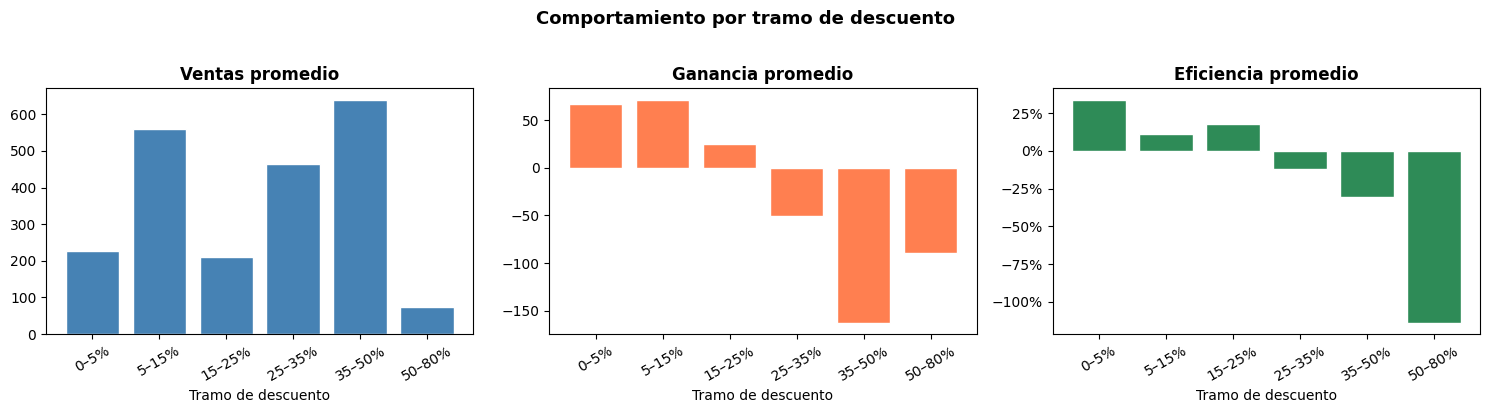

In [9]:
#Comportamiento por Tramo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = ['Ventas_prom', 'Profit_prom', 'Margen_prom']
titulos  = ['Ventas promedio', 'Ganancia promedio', 'Eficiencia promedio']
colores  = ['steelblue', 'coral', 'seagreen']

for ax, met, tit, col in zip(axes, metricas, titulos, colores):
  ax.bar(resumen_tramo['Tramo_descuento'].astype(str),
  resumen_tramo[met], color=col, edgecolor='white')

  ax.set_title(tit, fontweight='bold')
  ax.set_xlabel('Tramo de descuento')
  ax.tick_params(axis='x', rotation=30)

  if 'Margen' in met:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))


plt.suptitle('Comportamiento por tramo de descuento', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretación — Sección A

El gráfico revela un patrón consistente con la hipótesis:

- **Ventas promedio** crecen hasta el tramo 15–25 % y luego oscilan sin tendencia clara, lo que sugiere que el incremento en ingresos no es monotónico.
- **Ganancia promedio** cae de manera continua y se vuelve negativo a partir del tramo 35–50 %.
- **Eficiencia promedio** desciende sostenidamente: pasa de valores positivos (~15–25 %) en descuentos bajos a valores negativos en descuentos altos.

Esto valida la necesidad de encontrar el **punto de quiebre** donde la ganancia marginal de ventas ya no compensa la pérdida de margen.

##B) Rentabilidad

In [10]:
df["Margen"] = df["Profit"] / df["Sales"]

df.groupby("Tramo_descuento")[
    ["Sales","Profit","Margen"]
].mean()

,Sales,Profit,Margen
Tramo_descuento,,,
0–5%,226.742074,66.900292,0.340160
5–15%,561.149812,71.562798,0.112472
15–25%,209.076940,24.702572,0.176839
25–35%,463.465015,-50.237855,-0.121733
35–50%,638.944516,-162.744133,-0.307680
50–80%,75.033572,-89.438144,-1.138785


##C) Modelizacion economica
-  Sales: La curva tiene pendiente positiva pero descreciente, el incremento de las ventas se desacelera a meida que el descuento aumenta.n

- profit: curva decreciento que cruza el eje cero alrededor del 20%/25% de descuento, a partir de ahi cada transaccion destruye el valor.

- margen: Caida acelerada, el derioro del margen se acelera con descuentos altos,

In [11]:
# Preparación de datos

datos_mod = resumen_tramo.copy()

datos_mod = datos_mod.rename(columns={
    "Ventas_prom": "Sales_m",
    "Profit_prom": "Profit_m",
    "Margen_prom": "Margen_m"
})

x = np.arange(len(datos_mod))

def ajustar_modelo(x, y):
    coef = np.polyfit(x, y, 2)
    modelo = np.poly1d(coef)

    y_estimado = modelo(x)

    ss_res = np.sum((y - y_estimado) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    return modelo, r2

etiquetas = datos_mod["Tramo_descuento"].astype(str)
x_cont = np.linspace(x.min(), x.max(), 300)

## Ventas Promedio
- Como evolucionan las ventas promedio a medida que aumentan los descuentos.

In [12]:
# Tabla resumen por tramo de descuento
resumen_tramo = (
    df.groupby("Tramo_descuento", observed=True)
      .agg(
          Ventas_prom=("Sales", "mean"),
          Profit_prom=("Profit", "mean"),
          Margen_prom=("Margen", "mean"),
          Cantidad_prom=("Quantity", "mean"),
          N=("Sales", "count")
      )
      .reset_index()
)

resumen_tramo

,Tramo_descuento,Ventas_prom,Profit_prom,Margen_prom,Cantidad_prom,N
0,0–5%,226.742074,66.900292,0.340160,3.807211,4798
1,5–15%,561.149812,71.562798,0.112472,3.910959,146
2,15–25%,209.076940,24.702572,0.176839,3.735302,3657
3,25–35%,463.465015,-50.237855,-0.121733,3.755906,254
4,35–50%,638.944516,-162.744133,-0.307680,3.787986,283
5,50–80%,75.033572,-89.438144,-1.138785,3.912383,856


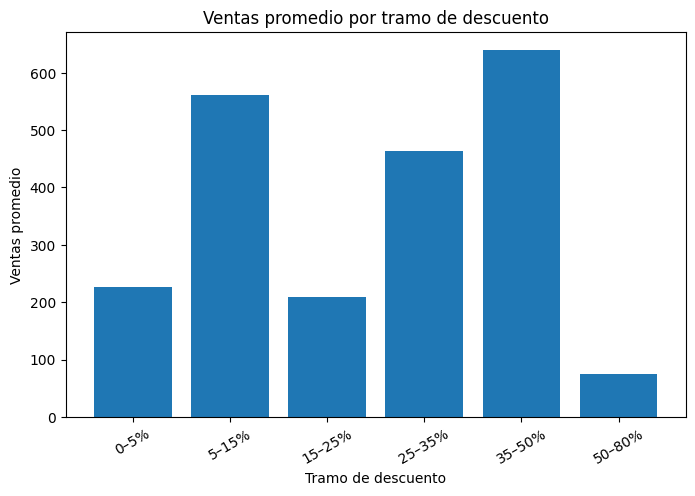

In [13]:
#Ventas Promedio

plt.figure(figsize=(8,5))

plt.bar(
    resumen_tramo["Tramo_descuento"].astype(str),
    resumen_tramo["Ventas_prom"]
)

plt.title("Ventas promedio por tramo de descuento")
plt.xlabel("Tramo de descuento")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=30)

plt.show()

## Ganancia de la venta(Profit) promedio
- Analisis en el cual Visualizamos si las ventas disminuyen a medida que aumentan los descuentos. (Tramo en donde el profit se vuelve negativo)

In [14]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Margen,Costo_estimado,Rentabilidad_relativa,Tramo_descuento
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,220.0464,0.190476,0–5%
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,512.3580,0.428571,0–5%
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,7.7486,0.886792,0–5%
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,1340.6085,-0.285714,35–50%
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,19.8516,0.126761,15–25%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.1625,21.1452,0.194030,15–25%
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.1700,76.3268,0.204819,0–5%
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.0750,239.1828,0.081081,15–25%
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.4500,16.2800,0.818182,0–5%


In [15]:
# Convertir la columna 'Order Date' a formato fecha (datetime)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extraer el año y crear la nueva columna
df['Año'] = df['Order Date'].dt.year

# Ahora sí puedes correr tu celda 16 sin problemas

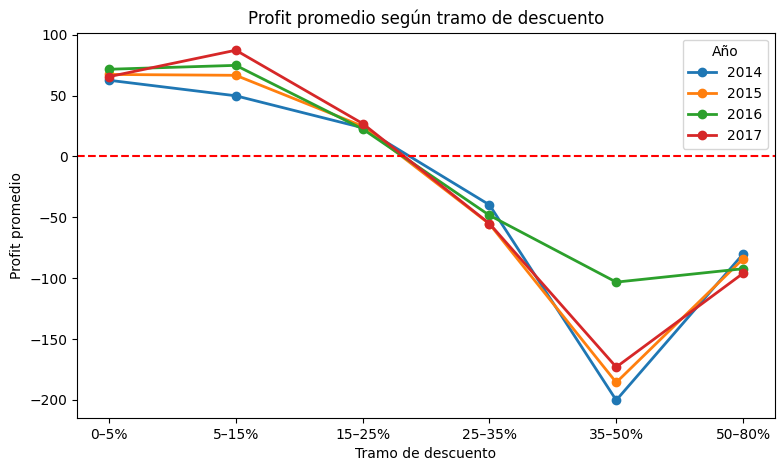

In [16]:
profit_anio = (
    df.groupby(["Año","Tramo_descuento"], observed=True)["Profit"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9,5))

for anio in sorted(profit_anio["Año"].unique()):
    datos = profit_anio[profit_anio["Año"] == anio]

    plt.plot(
        datos["Tramo_descuento"].astype(str),
        datos["Profit"],
        marker="o",
        linewidth=2,
        label=str(anio)
    )

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Profit promedio según tramo de descuento")
plt.xlabel("Tramo de descuento")
plt.ylabel("Profit promedio")
plt.legend(title="Año")

plt.show()

## Margen(procentaje de ganancia) Promedio
- Como cambia la rentabilidad a medida que aumentan los descuentos y permite identificar el punto en el cual los descuentos dejan de ser eficientes

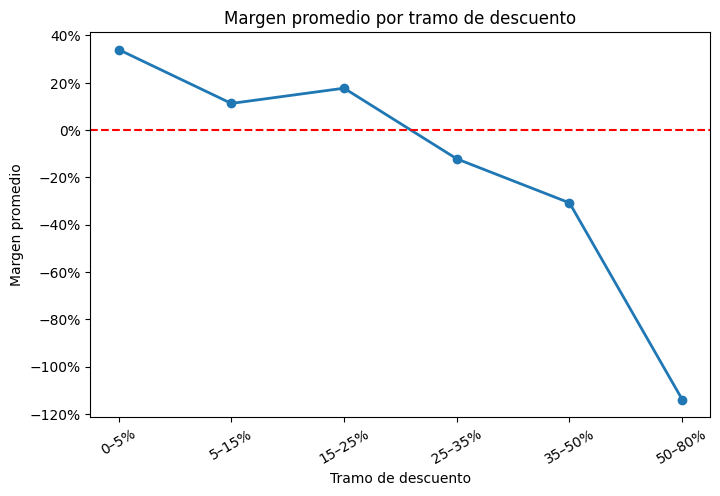

In [17]:
#Ganancia promedio por tramo de descuento

plt.figure(figsize=(8,5))

plt.plot(
    resumen_tramo["Tramo_descuento"].astype(str),
    resumen_tramo["Margen_prom"],
    marker="o",
    linewidth=2
)

plt.axhline(0, color="red", linestyle="--")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

plt.title("Margen promedio por tramo de descuento")
plt.xlabel("Tramo de descuento")
plt.ylabel("Margen promedio")
plt.xticks(rotation=30)

plt.show()


## Ventas + Margen Promedio

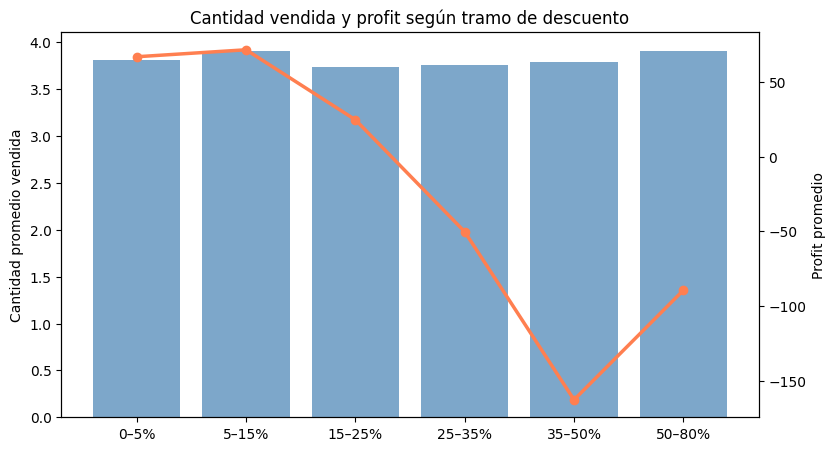

In [18]:
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(
    resumen_tramo["Tramo_descuento"].astype(str),
    resumen_tramo["Cantidad_prom"],
    color="steelblue",
    alpha=0.7
)

ax1.set_ylabel("Cantidad promedio vendida")

ax2 = ax1.twinx()

ax2.plot(
    resumen_tramo["Tramo_descuento"].astype(str),
    resumen_tramo["Profit_prom"],
    color="coral",
    marker="o",
    linewidth=2.5
)

ax2.set_ylabel("Profit promedio")

plt.title("Cantidad vendida y profit según tramo de descuento")

plt.show()

**CREACIÓN DE LAS VARIABLES ECONOMICAS (B,I,C)**

Luego del EDA, necesitamos modificar los datos existentes para realizar un riguroso analisis estadistico para evitar que nuestras conclusiones estén sesgadas por los valores extremos del dataframe

In [19]:
# Seleccionamos de la base de datos los valores del 5% de ambas colas para identificar posibles outliers en la variable 'Profit'
limite_inferior = df['Profit'].quantile(0.025)
limite_superior = df['Profit'].quantile(0.975)

# Filtramos los datos para quedarnos solo con los registros que están dentro de esos límites
df_filtrado = df[(df['Profit'] >= limite_inferior) & (df['Profit'] <= limite_superior)]


$Beneficio$

In [ ]:
# MODELIZACIÓN DEL BENEFICIO

# Definimos variables X e Y 
x = resumen['Discount']
y_profit = resumen['Profit_prom']

# Determinamos las variables y coeficientes del modelo polinomial de grado 2
coef_profit = np.polyfit(x, y_profit, 2)
a, b, c = coef_profit

print("MODELO DE BENEFICIO\n")
print(f"Función de beneficio: B(d) = {a:.2f}d^2 + {b:.2f}d + {c:.2f}")

MODELO DE BENEFICIO

Función de beneficio: B(d) = 964.98d^2 + -1064.88d + 143.29


$Costos$

In [ ]:
# MODELIZACIÓN DEL COSTO

#Definimos variables X e Y
y_costo = resumen['Costo_prom']

# Determinamos las variables y coeficientes del modelo polinomial de grado 2
coef_costo = np.polyfit(x, y_costo, 2)

print(f"Función de Costo:   C(d) = {coef_costo[0]:.2f}d^2 + {coef_costo[1]:.2f}d + {coef_costo[2]:.2f}")

Función de Costo:   C(d) = -3521.22d^2 + 2744.84d + 119.40


$Ingresos$

In [30]:
#MODELIZACIÓN DE LOS INGRESOS

#Definimos variables X e Y
y_ingresos = resumen['Ventas_prom']

#Determinamos las variables y coeficientes del modelo polinomial de grado 2
coef_ingresos = np.polyfit(x,y_ingresos, 2)

print(f"Función de Ingresos: I(d) = {coef_ingresos[0]:.2f}d^2 + {coef_ingresos[1]:.2f}d + {coef_ingresos[2]:.2f}")

Función de Ingresos: I(d) = -2556.24d^2 + 1679.96d + 262.69


In [35]:
# Optimizamos la función de beneficio para encontrar el descuento que maximiza el beneficio

# 1. Calculamos el punto crítico (donde la derivada es 0)
punto_critico = -b / (2 * a)
beneficio_en_punto = a*(punto_critico**2) + b*(punto_critico) + c

# 2. Condición de segundo orden (La segunda derivada de ax^2+bx+c es 2a)
segunda_derivada = 2 * a

if segunda_derivada < 0:
    print("   ¡La curva es cóncava hacia abajo (Forma de U invertida)!")
    print(f"   Descuento óptimo (Máximo): {punto_critico:.2%}")
    print(f"   Beneficio máximo: ${beneficio_en_punto:.2f}\n")
else:
    print("   La curva es cóncava hacia arriba (Forma de U).")
    print(f"   El punto hallado en {punto_critico:.2%} no es un máximo, ¡es el MÍNIMO (mayor pérdida)!")
    print(f"   Pérdida en ese punto: ${beneficio_en_punto:.2f}")
    print("  Conclusión: No hay un descuento óptimo interno. El beneficio se maximiza al 0% de descuento.")

   La curva es cóncava hacia arriba (Forma de U).
   El punto hallado en 55.18% no es un máximo, ¡es el MÍNIMO (mayor pérdida)!
   Pérdida en ese punto: $-150.49
  Conclusión: No hay un descuento óptimo interno. El beneficio se maximiza al 0% de descuento.


In [36]:
# El anterior metodo nos devolvió un punto crítico que es un mínimo. Utilicemos ahora un método de optimización numérica para encontrar el máximo beneficio dentro del rango de descuentos observados (0% a 80%).

resultado = minimize_scalar(lambda d: -(a*d**2 + b*d + c), bounds=(0, 0.8), method='bounded')  

descuento_optimo = resultado.x

beneficio_maximo = a*descuento_optimo**2 + b*descuento_optimo + c

print(f"\nDescuento óptimo: {descuento_optimo:.2%}")

print(f"Beneficio máximo: ${beneficio_maximo:.2f}") 





Descuento óptimo: 0.00%
Beneficio máximo: $143.28
